# **MNIST-1D**: Observing deep double descent

This notebook was originally proposed at MNIST 1D github repo and adapted by Gabriel V. Cardoso.

The goal of this notebook is to reproduce the double descent experiment with different networks.

In [ ]:
# uncomment the next line if you are in colab
#!pip install mnist1d
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from typing import Dict, Tuple

In [ ]:
from mnist1d.data import make_dataset, get_dataset_args

args = get_dataset_args()
args.num_samples = 16_000
args.train_split = 0.25

data = make_dataset(args)

print(data['x'].shape)
print(data['x_test'].shape)

(4000, 40)
(12000, 40)


In [ ]:
data['y']

array([5, 6, 2, ..., 3, 5, 7])

In [ ]:
# Add 15% noise to training labels

import copy
data_with_label_noise = copy.deepcopy(data)

for i in range(len(data['y'])):
    if np.random.random_sample() < 0.15:
        data_with_label_noise['y'][i] = np.random.randint(0, 10)

In [ ]:
# Define MLP architecture with one hidden layer

def get_model(n_hidden):
    return nn.Sequential(
        nn.Linear(40, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, n_hidden),
        nn.ReLU(),
        nn.Linear(n_hidden, 10)
    )

## Question 1:

Write a `fit_model` function according to the docstring defined below.

In [53]:
def fit_model(
    model: torch.nn.Module,
    data: Dict[str, np.ndarray],
    n_epoch: int,
    optimizer_params: Dict[str, float],
    return_last_only: bool = True,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    This function must return the train and test error.
    Args:
        model (torch.nn.Module): The model being used to classify.
        data (Dict[str, np.ndarray]): A dictionary with keys ["x", "y", "x_test", "y_test"]
        n_epoch (int): number of epochs to test
        optimizer_params (Dict[str, float]): Dictionary with parameters for the optimizer, such as ["lr", "momentum"...].

    Returns:
        Tuple[torch.Tensor, torch.Tensor]: Return train and test error of the trained model.
    """
    x_train = torch.tensor(data["x"], dtype=torch.float32).unsqueeze(1)
    x_test = torch.tensor(data["x_test"], dtype=torch.float32).unsqueeze(1)
    y_train = torch.tensor(data["y"], dtype=torch.long)
    y_test = torch.tensor(data["y_test"], dtype=torch.long)
    train_dataset = TensorDataset(x_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), **optimizer_params)

    train_errors = []
    test_errors = []

    for epoch in range(n_epoch):
        model.train()

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            train_pred = model(x_train).argmax(dim=1)
            test_pred = model(x_test).argmax(dim=1)

            train_error = (train_pred != y_train).float().mean()
            test_error = (test_pred != y_test).float().mean()

        train_errors.append(train_error)
        test_errors.append(test_error)

    train_errors = torch.stack(train_errors)
    test_errors = torch.stack(test_errors)

    if return_last_only:
        return train_errors[-1], test_errors[-1]
    else:
        return train_errors, test_errors

## Question 2:

Test your implementation and parameterization: Running it with MLP of size 100 should give you 0 train error. Make sure this is the case and that 0 train error is obtained not in the end of the traning

In [ ]:
model = get_model(100)
train_errors, test_errors = fit_model(
    model,
    data_with_label_noise,
    n_epoch=150,
    optimizer_params={"lr": 0.2, "momentum": 0.9},
    return_last_only=False
)


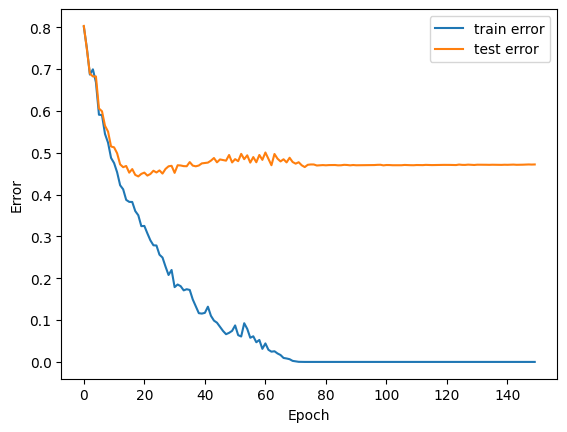

In [ ]:
plt.plot(train_errors.numpy(), label="train error")
plt.plot(test_errors.numpy(), label="test error")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.show()


## Question 3:

Investigate double descent on the MLP class for no noise and noisy data.

In [46]:
errors_train = []
errors_test = []
L_neurons =[2,5,10,25,50,100,200,300,400,500,600,700]
for nb_neuron in L_neurons:
  model = get_model(nb_neuron)

  train_errors, test_errors = fit_model(
      model,
      data,
      n_epoch=150,
      optimizer_params={"lr": 0.1, "momentum": 0.9},
      return_last_only=True
  )
  print(f'The Train error and the Test error for {nb_neuron} hidden neurons are respectively : {train_errors} and {test_errors}')
  errors_train.append(train_errors)
  errors_test.append(test_errors)



The Train error and the Test error for 2 hidden neurons are respectively : 0.6797500252723694 and 0.6880833506584167
The Train error and the Test error for 5 hidden neurons are respectively : 0.5120000243186951 and 0.5440833568572998
The Train error and the Test error for 10 hidden neurons are respectively : 0.4244999885559082 and 0.5007500052452087
The Train error and the Test error for 25 hidden neurons are respectively : 0.1965000033378601 and 0.4100833237171173
The Train error and the Test error for 50 hidden neurons are respectively : 0.0022499999031424522 and 0.39366665482521057
The Train error and the Test error for 100 hidden neurons are respectively : 0.0 and 0.3881666660308838
The Train error and the Test error for 200 hidden neurons are respectively : 0.0 and 0.3696666657924652
The Train error and the Test error for 300 hidden neurons are respectively : 0.0 and 0.3595833480358124
The Train error and the Test error for 400 hidden neurons are respectively : 0.0 and 0.354416668

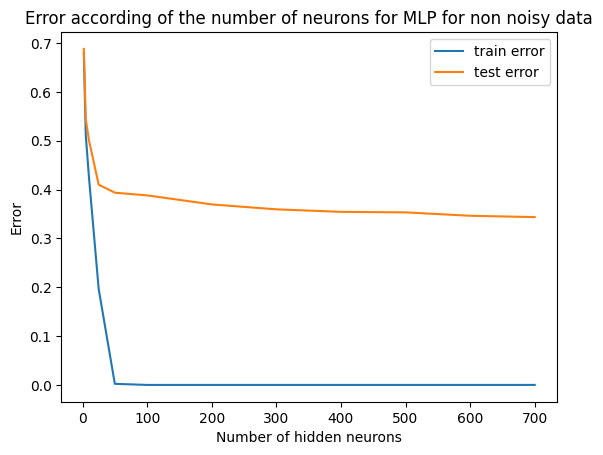

In [47]:
plt.plot(L_neurons, errors_train, label="train error")
plt.plot(L_neurons,errors_test, label="test error")
plt.legend()
plt.xlabel("Number of hidden neurons")
plt.ylabel("Error")
plt.title('Error according of the number of neurons for MLP for non noisy data' )
plt.show()

In [48]:
errors_train = []
errors_test = []
L_neurons =[2,5,10,25,50,100,200,300,400,500,600,700]
for nb_neuron in L_neurons:
  model = get_model(nb_neuron)

  train_errors, test_errors = fit_model(
      model,
      data_with_label_noise,
      n_epoch=150,
      optimizer_params={"lr": 0.1, "momentum": 0.9},
      return_last_only=True
  )
  print(f'The Train error and the Test error for {nb_neuron} hidden neurons are respectively : {train_errors} and {test_errors}')
  errors_train.append(train_errors)
  errors_test.append(test_errors)


The Train error and the Test error for 2 hidden neurons are respectively : 0.7135000228881836 and 0.6966666579246521
The Train error and the Test error for 5 hidden neurons are respectively : 0.6302499771118164 and 0.6381666660308838
The Train error and the Test error for 10 hidden neurons are respectively : 0.515749990940094 and 0.5364166498184204
The Train error and the Test error for 25 hidden neurons are respectively : 0.36149999499320984 and 0.5308333039283752
The Train error and the Test error for 50 hidden neurons are respectively : 0.1379999965429306 and 0.5350000262260437
The Train error and the Test error for 100 hidden neurons are respectively : 0.0 and 0.48491665720939636
The Train error and the Test error for 200 hidden neurons are respectively : 0.0 and 0.4566666781902313
The Train error and the Test error for 300 hidden neurons are respectively : 0.0 and 0.4482499957084656
The Train error and the Test error for 400 hidden neurons are respectively : 0.0 and 0.446249991655

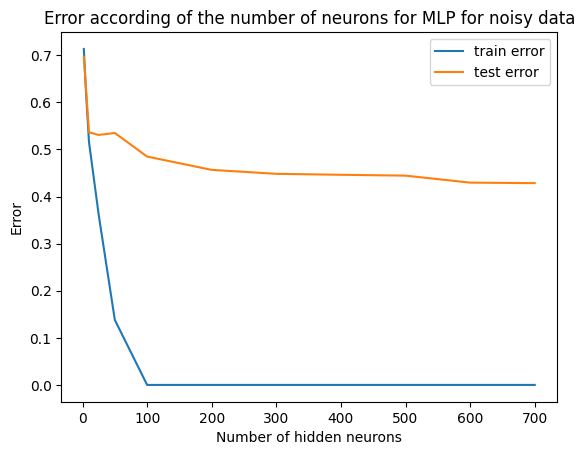

In [50]:
plt.plot(L_neurons, errors_train, label="train error")
plt.plot(L_neurons,errors_test, label="test error")
plt.legend()
plt.xlabel("Number of hidden neurons")
plt.ylabel("Error")
plt.title('Error according of the number of neurons for MLP for noisy data' )
plt.show()

## Question 4

Do the same for CNN.

In [54]:
# Define CNN architecture

def get_model_cnn(channels):
    return nn.Sequential(
        nn.Conv1d(1, channels, 5, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv1d(channels, channels, 3, stride=2, padding=1),
        nn.ReLU(),
        nn.Conv1d(channels, channels, 3, stride=2, padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(channels * 5, 10),
    )

In [57]:
errors_train = []
errors_test = []
L_channels = [1,2,3,5,10,25,50,100,200]
for channel in L_channels:
  model = get_model_cnn(channel)

  train_errors, test_errors = fit_model(
      model,
      data,
      n_epoch=150,
      optimizer_params={"lr": 0.1, "momentum": 0.9},
      return_last_only=True
  )
  print(f'The Train error and the Test error for {channel} channels are respectively : {train_errors} and {test_errors}')
  errors_train.append(train_errors)
  errors_test.append(test_errors)



The Train error and the Test error for 1 channels are respectively : 0.8892499804496765 and 0.9035833477973938
The Train error and the Test error for 2 channels are respectively : 0.6527500152587891 and 0.6607499718666077
The Train error and the Test error for 3 channels are respectively : 0.43549999594688416 and 0.46141666173934937
The Train error and the Test error for 5 channels are respectively : 0.32475000619888306 and 0.3634166717529297
The Train error and the Test error for 10 channels are respectively : 0.026000000536441803 and 0.10649999976158142
The Train error and the Test error for 25 channels are respectively : 0.0 and 0.09016666561365128
The Train error and the Test error for 50 channels are respectively : 0.0 and 0.10350000113248825
The Train error and the Test error for 100 channels are respectively : 0.0 and 0.0845833346247673
The Train error and the Test error for 200 channels are respectively : 0.0 and 0.09316666424274445


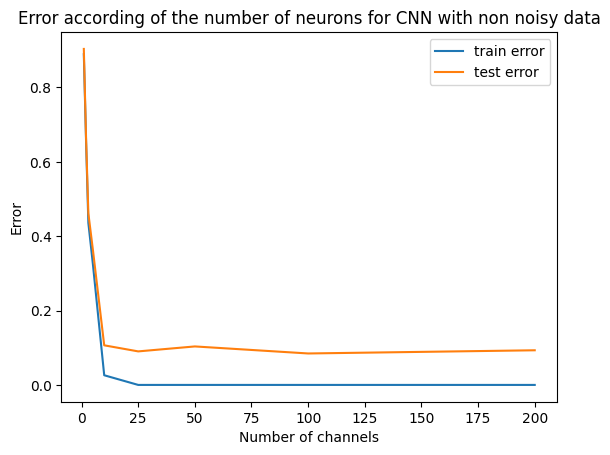

In [59]:
plt.plot(L_channels, errors_train, label="train error")
plt.plot(L_channels,errors_test, label="test error")
plt.legend()
plt.xlabel("Number of channels")
plt.ylabel("Error")
plt.title('Error according of the number of neurons for CNN with non noisy data')
plt.show()

In [60]:
errors_train = []
errors_test = []
L_channels = [1,2,3,5,10,25,50,100]
for channel in L_channels:
  model = get_model_cnn(channel)

  train_errors, test_errors = fit_model(
      model,
      data_with_label_noise,
      n_epoch=150,
      optimizer_params={"lr": 0.1, "momentum": 0.9},
      return_last_only=True
  )
  print(f'The Train error and the Test error for {channel} channels are respectively : {train_errors} and {test_errors}')
  errors_train.append(train_errors)
  errors_test.append(test_errors)



The Train error and the Test error for 1 channels are respectively : 0.8924999833106995 and 0.9035833477973938
The Train error and the Test error for 2 channels are respectively : 0.6995000243186951 and 0.6924999952316284
The Train error and the Test error for 3 channels are respectively : 0.5590000152587891 and 0.5250833630561829
The Train error and the Test error for 5 channels are respectively : 0.4232499897480011 and 0.38083332777023315
The Train error and the Test error for 10 channels are respectively : 0.2397499978542328 and 0.19625000655651093
The Train error and the Test error for 25 channels are respectively : 0.08550000190734863 and 0.289166659116745
The Train error and the Test error for 50 channels are respectively : 0.0 and 0.26466667652130127
The Train error and the Test error for 100 channels are respectively : 0.0 and 0.24549999833106995


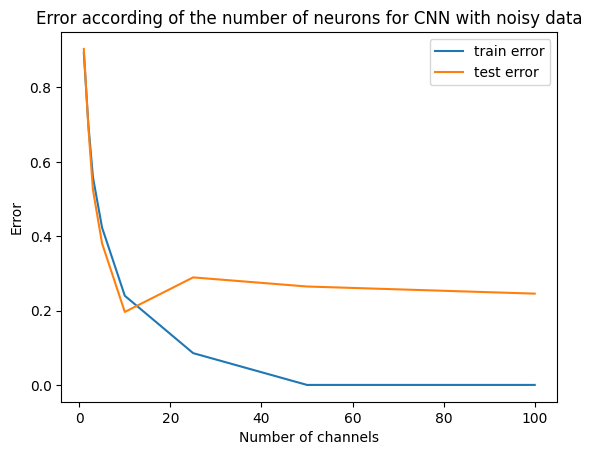

In [62]:
plt.plot(L_channels, errors_train, label="train error")
plt.plot(L_channels,errors_test, label="test error")
plt.legend()
plt.xlabel("Number of channels")
plt.ylabel("Error")
plt.title('Error according of the number of neurons for CNN with noisy data')
plt.show()

## Question 5:

Write a short report about your findings and the impact of the different factors.

We compared the behavior of MLP and CNN models when increasing the model size. In both models, when the number of neurons or channels increases, the training error quickly goes to zero. This means the models become expressive enough to perfectly fit the training data.

For the MLP, we observe a slight double descent effect. The test error first decreases, then slightly increases near the interpolation threshold, and finally decreases again when the network becomes very large. This effect is more visible when label noise is added.

For the CNN, the behavior is slightly different. The training error also goes to zero when the number of channels increases, but the test error is more stable and the double descent effect is weaker. CNNs tend to generalize better because the convolutional structure introduces an inductive bias that helps capture patterns in the data.

When noise is added to the labels, both models still reach zero training error, meaning they can memorize the noisy labels. However, the test error increases compared to the non-noisy case because the models start fitting the noise in the training data. Overall, noisy data leads to worse generalization for both architectures.